<a href="https://colab.research.google.com/github/baekka1/Crop-Yield-Prediction/blob/main/Classical_regression_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
gridmet_data = pd.read_csv("/content/drive/MyDrive/Data Science Capstone/gridMET.csv")
yield_data = pd.read_csv('/content/drive/MyDrive/Data Science Capstone/label_1980_2018_rawyield.csv')

In [5]:
gridmet_data

,id2,year,yield,tmmx-10-04,tmmx-11-04,tmmx-12-04,tmmx-13-04,tmmx-14-04,tmmx-15-04,tmmx-16-04,...,th-27-10,th-28-10,th-29-10,th-30-10,th-31-10,th-01-11,th-02-11,th-03-11,th-04-11,th-05-11
0,112,1980,27.0,297.150746,288.676866,286.200000,282.085821,294.295522,296.445522,294.279851,...,336.291045,29.574627,244.283582,224.067164,221.201493,212.723881,228.544776,302.686567,259.014925,211.365672
1,113,1980,28.0,297.274444,288.907778,285.003333,280.973333,293.290000,294.762222,293.843333,...,328.100000,297.333333,281.933333,246.333333,243.800000,211.500000,227.733333,295.566667,279.533333,198.266667
2,119,1980,29.0,295.384158,290.352475,283.873267,281.912871,292.167327,292.957426,295.866337,...,350.772277,14.564356,353.693069,225.841584,230.623762,150.069307,194.930693,289.900990,305.217822,175.801980
3,120,1980,28.0,296.932727,290.636364,282.992727,282.347273,293.369091,295.369091,294.618182,...,321.109091,9.345455,344.872727,248.000000,249.872727,212.509091,215.654545,312.745455,312.200000,187.600000
4,124,1980,24.0,295.936275,290.024510,283.841176,282.185294,292.311765,294.537255,296.009804,...,333.196078,13.196078,326.127451,219.882353,219.745098,176.735294,192.009804,290.950980,307.000000,169.245098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45333,3121,2018,182.0,287.481818,288.018182,277.063636,275.174747,273.435354,273.714141,276.369697,...,247.565657,216.000000,160.353535,303.808081,163.747475,207.292929,150.959596,68.696970,143.525253,222.484848
45334,3122,2018,156.8,283.802586,280.986207,276.347414,272.293966,270.118966,273.640517,276.302586,...,195.543103,217.198276,169.939655,286.482759,157.887931,252.327586,141.724138,73.000000,160.353448,229.103448
45335,3123,2018,163.4,284.855263,282.180702,276.589474,272.520175,269.822807,273.605263,276.004386,...,237.815789,212.184211,173.289474,289.824561,164.131579,210.991228,108.508772,78.728070,156.833333,231.228070
45336,3124,2018,160.4,283.798990,281.497980,276.852525,272.847475,270.563636,274.037374,276.393939,...,197.636364,215.575758,158.484848,288.727273,155.878788,226.848485,175.696970,68.757576,153.909091,228.757576


In [6]:
yield_data

,Unnamed: 0,index,id2,year,yield
0,0,1,112,1980,27.0
1,1,2,113,1980,28.0
2,2,3,119,1980,29.0
3,3,4,120,1980,28.0
4,4,5,124,1980,24.0
...,...,...,...,...,...
45333,874,54751,3121,2018,182.0
45334,875,54752,3122,2018,156.8
45335,876,54753,3123,2018,163.4
45336,877,54754,3124,2018,160.4


In [11]:
def create_gridmet_annual_features(gridmet_data, variables, id_cols=['id2', 'year', 'yield']):
    df = gridmet_data.copy()
    ts_cols = [col for col in df.columns if col not in id_cols]

    grouped_features = defaultdict(list)
    for col in ts_cols:
        for var in variables:
            if col.startswith(var + '-'):
                grouped_features[var].append(col)

    def extract_summary_stats(sub_df, prefix):
        stats = pd.DataFrame(index=sub_df.index)
        stats[f'{prefix}_mean'] = sub_df.mean(axis=1)
        stats[f'{prefix}_std'] = sub_df.std(axis=1)
        stats[f'{prefix}_min'] = sub_df.min(axis=1)
        stats[f'{prefix}_max'] = sub_df.max(axis=1)
        stats[f'{prefix}_25q'] = sub_df.quantile(0.25, axis=1)
        stats[f'{prefix}_50q'] = sub_df.quantile(0.50, axis=1)
        stats[f'{prefix}_75q'] = sub_df.quantile(0.75, axis=1)
        stats[f'{prefix}_skew'] = sub_df.skew(axis=1)
        stats[f'{prefix}_kurt'] = sub_df.kurt(axis=1)
        return stats

    feature_stats_list = []
    for var, cols in grouped_features.items():
        if cols:
            stats = extract_summary_stats(df[cols], var)
            feature_stats_list.append(stats)

    features_reduced = pd.concat(feature_stats_list, axis=1)

    features_reduced['id2'] = df['id2']
    features_reduced['year'] = df['year']
    features_reduced['yield'] = df['yield']

    df_yield = df[['id2', 'year', 'yield']].sort_values(['id2', 'year'])
    df_yield['yield_prev_year'] = df_yield.groupby('id2')['yield'].shift(1)
    df_yield['yield_5yr_mean'] = df_yield.groupby('id2')['yield'].shift(1).rolling(5, min_periods=1).mean().reset_index(0, drop=True)

    def add_yield_trend(group):
        proj = []
        for _, row in group.iterrows():
            past = group[group['year'] < row['year']]
            if len(past) >= 3:
                slope, intercept = np.polyfit(past['year'], past['yield'], 1)
                proj.append(slope * row['year'] + intercept)
            else:
                proj.append(np.nan)
        group['yield_trend_pred'] = proj
        return group

    df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)

    gridmet_aug = features_reduced.merge(df_yield.drop(columns='yield'), on=['id2', 'year'], how='left')

    # Rearrange columns
    col_list = gridmet_aug.columns
    new_order = ['id2', 'year'] + [c for c in col_list if c not in ['id2', 'year', 'yield']] + ['yield']
    gridmet_aug = gridmet_aug[new_order]
    gridmet_aug = gridmet_aug.dropna().reset_index(drop=True)

    return gridmet_aug

In [12]:
variables = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs',
             'th', 'vpd']

id_cols=['id2', 'year', 'yield']

# To create annual features
gridmet_aug = create_gridmet_annual_features(gridmet_data, variables)
gridmet_aug = gridmet_aug[gridmet_aug['id2'] != 3066]

In [9]:
gridmet_aug

,id2,year,tmmx_mean,tmmx_std,tmmx_min,tmmx_max,tmmx_25q,tmmx_50q,tmmx_75q,tmmx_skew,...,th_max,th_25q,th_50q,th_75q,th_skew,th_kurt,yield_prev_year,yield_5yr_mean,yield_trend_pred,yield
0,112,1983,300.639303,6.391192,282.501493,311.154478,296.622948,301.404104,305.814552,-0.547203,...,351.985075,158.871269,184.414179,203.533582,-0.244572,1.058199,73.0,85.20,100.333333,60.0
1,119,1983,302.029915,7.084143,282.042574,313.670297,297.439109,302.825743,307.994802,-0.498696,...,352.346535,111.688119,190.341584,221.514851,-0.111961,-0.543424,114.0,88.20,159.666667,93.0
2,120,1983,301.208597,6.323017,281.998182,311.830909,297.142727,302.315455,306.139545,-0.568569,...,356.436364,152.968182,196.181818,226.704545,-0.148566,0.156852,90.0,95.00,118.000000,43.0
3,124,1983,302.114678,6.757675,282.335294,313.860784,297.865931,303.305392,307.536765,-0.556260,...,352.166667,129.399510,189.872549,215.149510,-0.148656,-0.247080,86.0,96.80,125.666667,72.0
4,136,1983,302.057880,6.876750,282.221429,313.348810,297.736607,303.182738,307.591071,-0.521440,...,350.535714,117.354167,192.250000,220.452381,-0.190834,-0.480399,80.0,96.00,115.333333,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41262,3121,2018,294.953877,7.903960,273.435354,307.487879,288.758586,296.868182,301.115909,-0.699714,...,325.585859,115.785354,177.520202,230.707071,-0.016760,-0.947121,181.5,125.94,160.210384,182.0
41263,3122,2018,294.790673,8.390165,270.118966,308.180172,288.875647,297.051293,301.053879,-0.759059,...,317.560345,117.767241,195.073276,243.765086,-0.132563,-1.141658,165.7,127.86,152.408819,156.8
41264,3123,2018,294.716057,8.376341,269.822807,308.200877,288.603947,296.722807,300.911404,-0.759404,...,317.333333,113.414474,188.328947,245.151316,-0.125809,-1.122236,161.5,129.76,157.790327,163.4
41265,3124,2018,294.695984,8.227454,270.563636,307.890909,288.658081,296.950505,300.931061,-0.740544,...,314.848485,122.719697,184.712121,234.174242,-0.078467,-0.955658,164.0,131.56,149.548583,160.4


In [13]:
df=gridmet_aug
print(df)

        id2  year   tmmx_mean  tmmx_std    tmmx_min    tmmx_max    tmmx_25q  \
0       112  1983  300.639303  6.391192  282.501493  311.154478  296.622948   
1       119  1983  302.029915  7.084143  282.042574  313.670297  297.439109   
2       120  1983  301.208597  6.323017  281.998182  311.830909  297.142727   
3       124  1983  302.114678  6.757675  282.335294  313.860784  297.865931   
4       136  1983  302.057880  6.876750  282.221429  313.348810  297.736607   
...     ...   ...         ...       ...         ...         ...         ...   
41262  3121  2018  294.953877  7.903960  273.435354  307.487879  288.758586   
41263  3122  2018  294.790673  8.390165  270.118966  308.180172  288.875647   
41264  3123  2018  294.716057  8.376341  269.822807  308.200877  288.603947   
41265  3124  2018  294.695984  8.227454  270.563636  307.890909  288.658081   
41266  3125  2018  294.558141  8.458098  269.417778  307.997037  288.806852   

         tmmx_50q    tmmx_75q  tmmx_skew  ...      

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR

Running model: Ridge


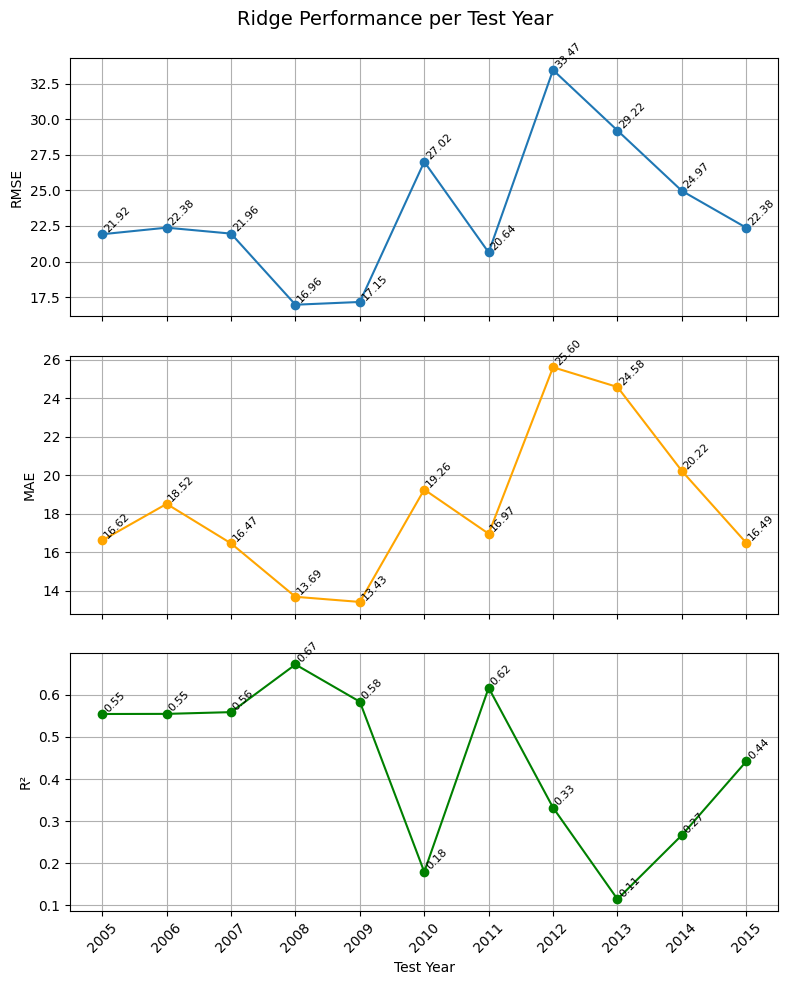

Running model: Lasso


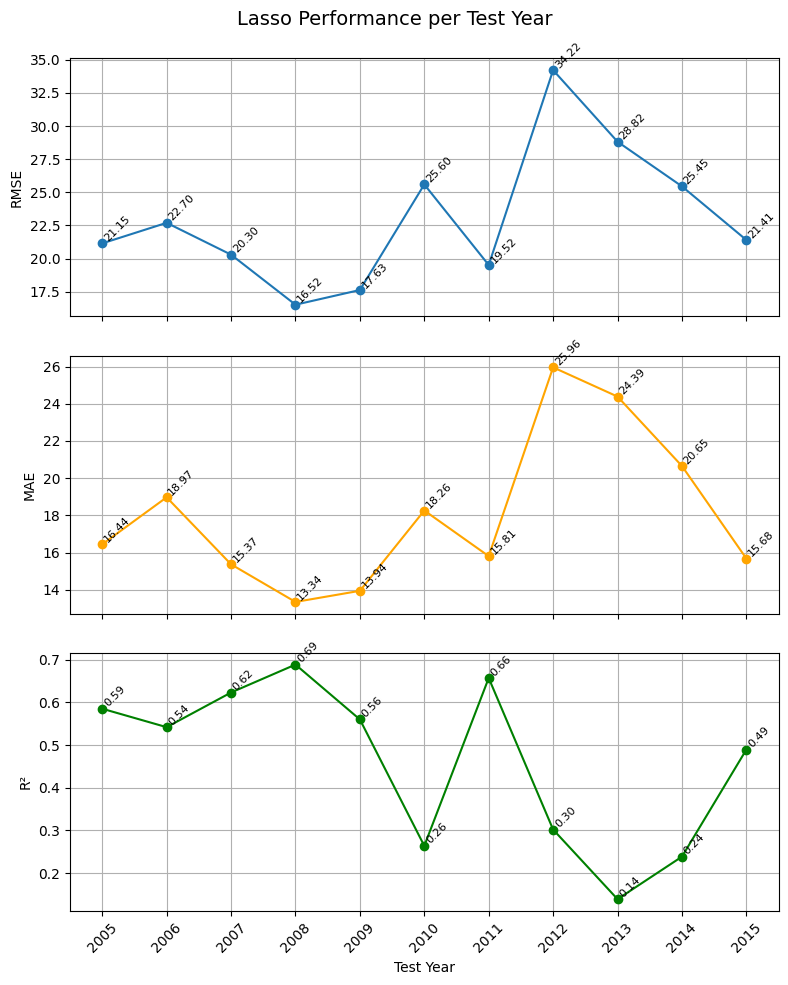

Running model: ElasticNet


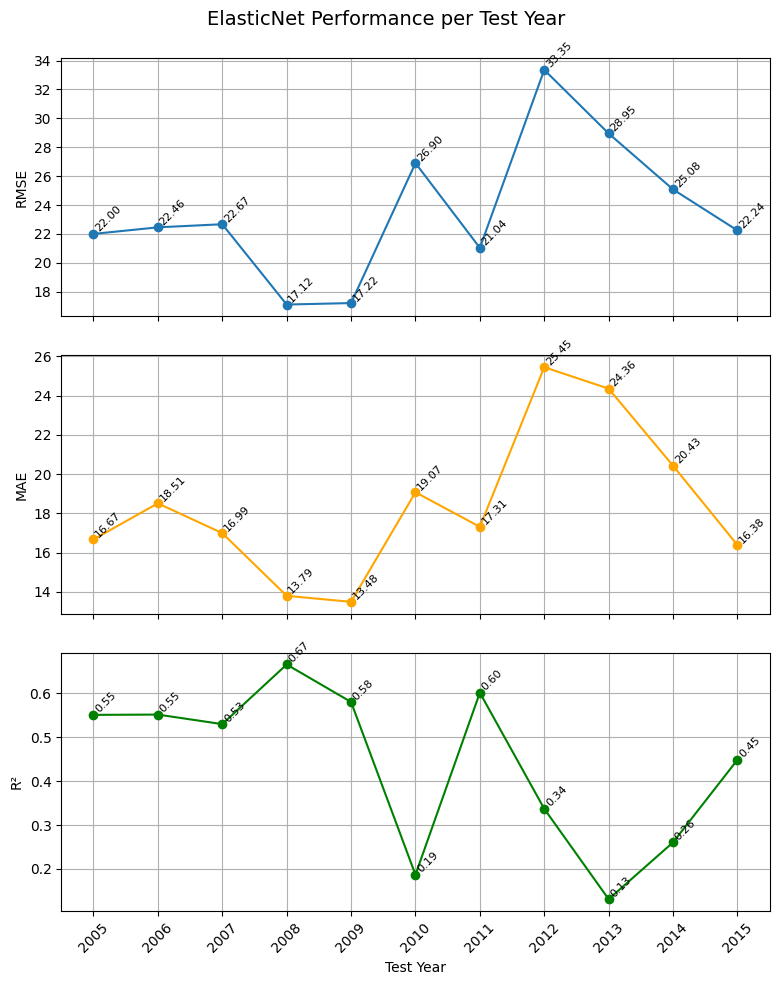

Running model: SVR


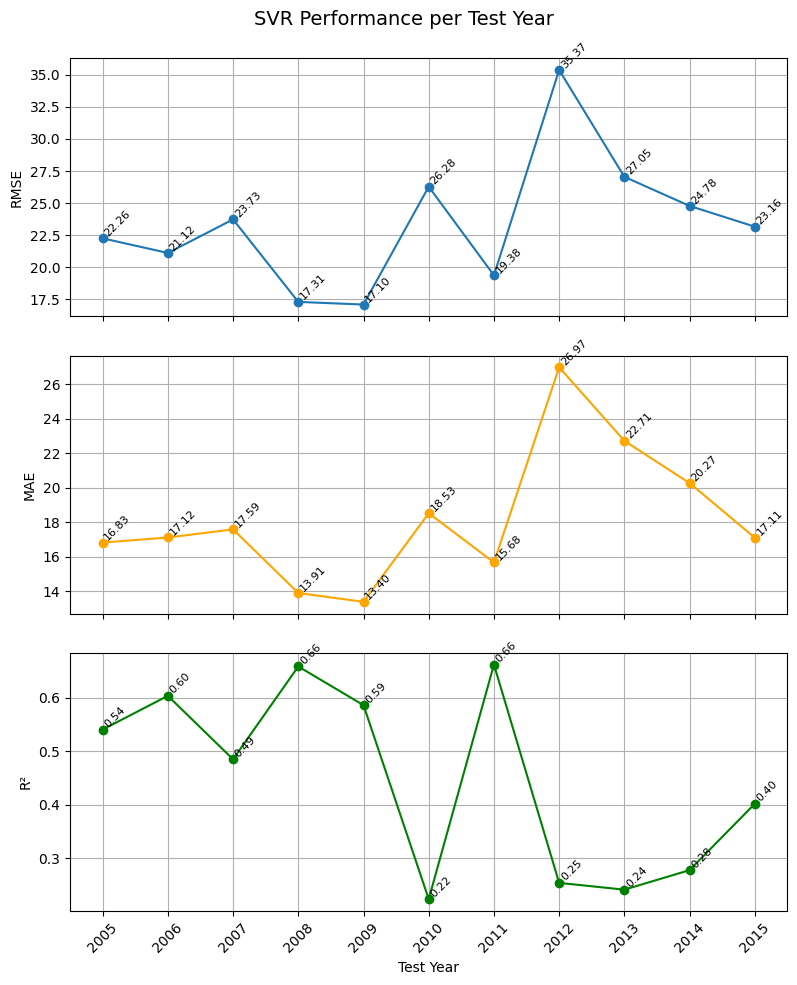


=== Leave-One-Year-Out CV Results ===
        Model       RMSE        MAE        R2
0       Ridge  23.934770  18.338971  0.542544
1       Lasso  23.549370  18.058410  0.557157
2  ElasticNet  24.003779  18.396537  0.539902
3         SVR  23.942677  18.185538  0.542241


In [15]:
##Leave-one-year-out cv (2005-2015)

test_years = list(range(2005, 2016))

models = {
    "Ridge": Ridge(alpha=200.0),
    "Lasso": Lasso(alpha=0.15),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "SVR": LinearSVR(
    C=10.0,
    epsilon=0.1,
    max_iter=5000,
    random_state=42)
}

results = []

#years = df['year'].unique().tolist()

non_model_cols = ['yield']

for name, model in models.items():
    print(f"Running model: {name}")

    y_true_all = []
    y_pred_all = []

    year_metrics = []

    for test_year in test_years:
      train_start = test_year - 15
      train_end = test_year - 1

      # Train on 15 previous years
      train_data = df[(df["year"] >= train_start) & (df["year"] <= train_end)]
      test_data = df[df["year"] == test_year]

      X_train = train_data.drop(columns = non_model_cols)
      X_test = test_data.drop(columns = non_model_cols)
      y_train = train_data["yield"]
      y_test = test_data["yield"]

      # Scale features
      scaler = StandardScaler()
      X_train_scaled = scaler.fit_transform(X_train)
      X_test_scaled = scaler.transform(X_test)

      # Fit and predict
      model.fit(X_train_scaled, y_train)
      y_pred = model.predict(X_test_scaled)

      y_true_all.extend(y_test)
      y_pred_all.extend(y_pred)

      rmse = np.sqrt(mean_squared_error(y_test, y_pred))
      mae = mean_absolute_error(y_test, y_pred)
      r2 = r2_score(y_test, y_pred)

      year_metrics.append({
      "Year": test_year,
      "RMSE": rmse,
      "MAE": mae,
      "R2": r2})

    metrics_df = pd.DataFrame(year_metrics)
    globals()[f"{name}_metrics_df"] = metrics_df

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(metrics_df["Year"], metrics_df["RMSE"], marker='o')
    for x, rmse_val in zip(metrics_df["Year"], metrics_df["RMSE"]):
      axes[0].text(x, rmse_val, f"{rmse_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[0].set_ylabel("RMSE")

    axes[1].plot(metrics_df["Year"], metrics_df["MAE"], marker='o', color='orange')
    for x, mae_val in zip(metrics_df["Year"], metrics_df["MAE"]):
        axes[1].text(x, mae_val, f"{mae_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[1].set_ylabel("MAE")

    axes[2].plot(metrics_df["Year"], metrics_df["R2"], marker='o', color='green')
    for x, r2_val in zip(metrics_df["Year"], metrics_df["R2"]):
        axes[2].text(x, r2_val, f"{r2_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[2].set_ylabel("R²")
    axes[2].set_xlabel("Test Year")

    for ax in axes:
      ax.set_xticks(test_years)
      ax.set_xticklabels(test_years, rotation=45)
      ax.grid(True)

    plt.suptitle(f"{name} Performance per Test Year", fontsize=14)
    plt.tight_layout()
    plt.show()

 # Compute metrics over all years
    rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    mae_all = mean_absolute_error(y_true_all, y_pred_all)
    r2_all = r2_score(y_true_all, y_pred_all)

    results.append({"Model": name, "RMSE": rmse_all, "MAE": mae_all, "R2": r2_all})

# ================================
# 7. Summarize results
# ================================
results_df = pd.DataFrame(results)
print("\n=== Leave-One-Year-Out CV Results ===")
print(results_df)

Running model: Ridge


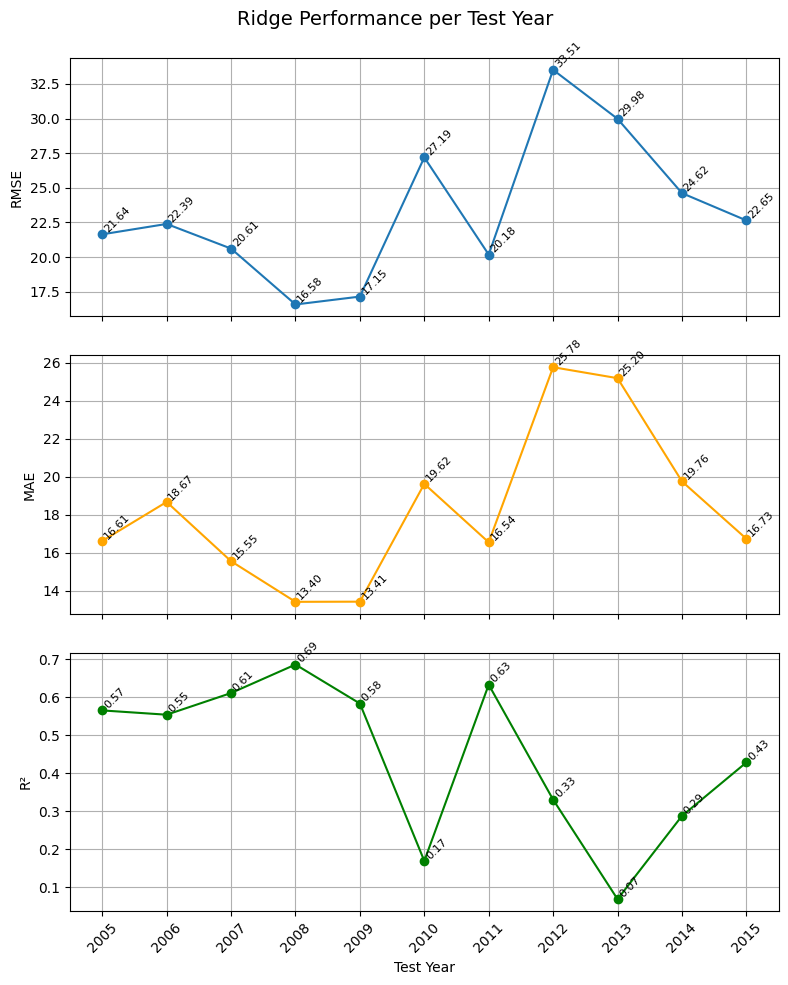

Running model: Lasso


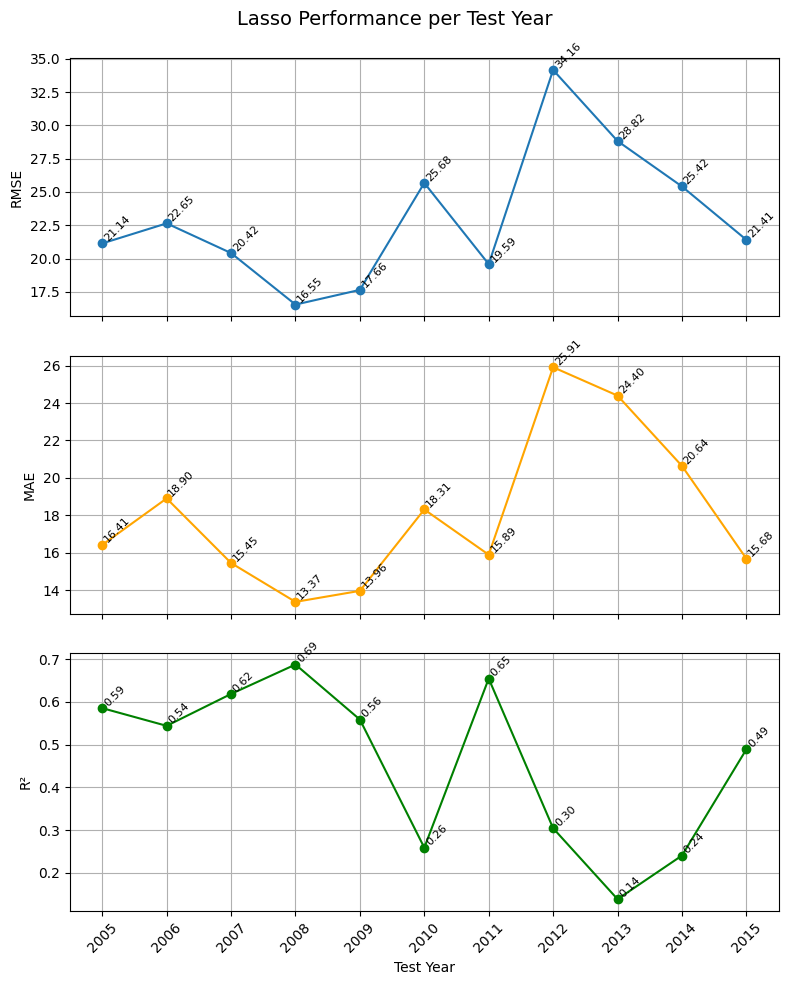

Running model: ElasticNet


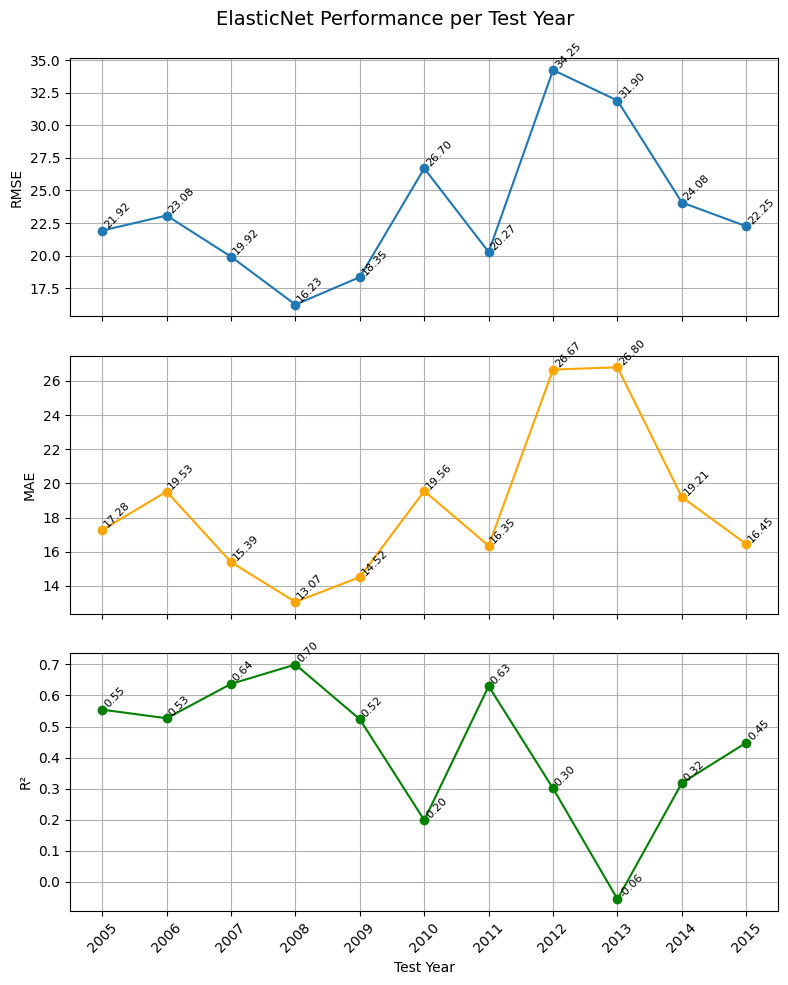

Running model: SVR


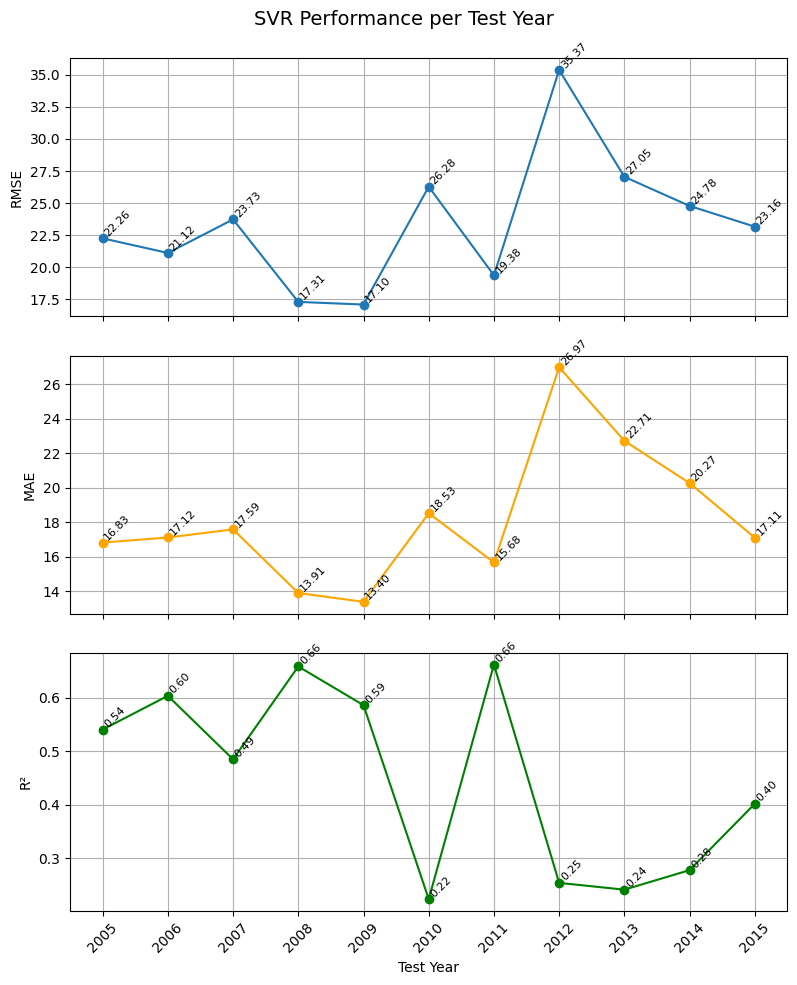


=== Leave-One-Year-Out CV Results ===
        Model       RMSE        MAE        R2
0       Ridge  23.828749  18.279927  0.546587
1       Lasso  23.559636  18.067421  0.556771
2  ElasticNet  24.100986  18.606989  0.536168
3         SVR  23.942677  18.185538  0.542241


In [66]:
##testing Leave-one-year-out cv (2005-2015)

test_years = list(range(2005, 2016))

models = {
    "Ridge": Ridge(alpha=200),
    "Lasso": Lasso(alpha=0.142),
    "ElasticNet": ElasticNet(alpha=0.247, l1_ratio=0.),
    "SVR": LinearSVR(
    C=10.0,
    epsilon=0.1,
    max_iter=5000,
    random_state=42)
}

results = []

#years = df['year'].unique().tolist()

non_model_cols = ['yield']

for name, model in models.items():
    print(f"Running model: {name}")

    y_true_all = []
    y_pred_all = []

    year_metrics = []

    for test_year in test_years:
      train_start = test_year - 15
      train_end = test_year - 1

      # Train on 15 previous years
      train_data = df[(df["year"] >= train_start) & (df["year"] <= train_end)]
      test_data = df[df["year"] == test_year]

      X_train = train_data.drop(columns = non_model_cols)
      X_test = test_data.drop(columns = non_model_cols)
      y_train = train_data["yield"]
      y_test = test_data["yield"]

      # Scale features
      scaler = StandardScaler()
      X_train_scaled = scaler.fit_transform(X_train)
      X_test_scaled = scaler.transform(X_test)

      # Fit and predict
      model.fit(X_train_scaled, y_train)
      y_pred = model.predict(X_test_scaled)

      y_true_all.extend(y_test)
      y_pred_all.extend(y_pred)

      rmse = np.sqrt(mean_squared_error(y_test, y_pred))
      mae = mean_absolute_error(y_test, y_pred)
      r2 = r2_score(y_test, y_pred)

      year_metrics.append({
      "Year": test_year,
      "RMSE": rmse,
      "MAE": mae,
      "R2": r2})

    metrics_df = pd.DataFrame(year_metrics)
    globals()[f"{name}_metrics_df"] = metrics_df

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(metrics_df["Year"], metrics_df["RMSE"], marker='o')
    for x, rmse_val in zip(metrics_df["Year"], metrics_df["RMSE"]):
      axes[0].text(x, rmse_val, f"{rmse_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[0].set_ylabel("RMSE")

    axes[1].plot(metrics_df["Year"], metrics_df["MAE"], marker='o', color='orange')
    for x, mae_val in zip(metrics_df["Year"], metrics_df["MAE"]):
        axes[1].text(x, mae_val, f"{mae_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[1].set_ylabel("MAE")

    axes[2].plot(metrics_df["Year"], metrics_df["R2"], marker='o', color='green')
    for x, r2_val in zip(metrics_df["Year"], metrics_df["R2"]):
        axes[2].text(x, r2_val, f"{r2_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[2].set_ylabel("R²")
    axes[2].set_xlabel("Test Year")

    for ax in axes:
      ax.set_xticks(test_years)
      ax.set_xticklabels(test_years, rotation=45)
      ax.grid(True)

    plt.suptitle(f"{name} Performance per Test Year", fontsize=14)
    plt.tight_layout()
    plt.show()

 # Compute metrics over all years
    rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    mae_all = mean_absolute_error(y_true_all, y_pred_all)
    r2_all = r2_score(y_true_all, y_pred_all)

    results.append({"Model": name, "RMSE": rmse_all, "MAE": mae_all, "R2": r2_all})

# ================================
# 7. Summarize results
# ================================
results_df = pd.DataFrame(results)
print("\n=== Leave-One-Year-Out CV Results ===")
print(results_df)

In [42]:
from sklearn.linear_model import RidgeCV, LassoCV
import numpy as np

# Candidate alpha values (log-spaced is best)
alphas = np.logspace(-4, 4, 100)

# Ridge
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_

# Lasso
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
best_alpha_lasso = lasso_cv.alpha_

print("Best Ridge alpha:", best_alpha_ridge)
print("Best Lasso alpha:", best_alpha_lasso)

Best Ridge alpha: 890.2150854450392
Best Lasso alpha: 0.14174741629268062


In [49]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter grids
alphas = np.logspace(-4, 4, 100)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# Elastic Net with time-series CV
elastic_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=tscv,
    max_iter=10000,
    n_jobs=-1
)

elastic_cv.fit(X_train, y_train)

# Best parameters
best_alpha = elastic_cv.alpha_
best_l1_ratio = elastic_cv.l1_ratio_

print("Best Elastic Net alpha:", best_alpha)
print("Best Elastic Net l1_ratio:", best_l1_ratio)

Best Elastic Net alpha: 0.24770763559917114
Best Elastic Net l1_ratio: 0.1
